# 18 - Structural paradigm shift: phlogiston as a Gaussian Bayes net

Each agent's paradigm is a **Gaussian belief in information form** $(\Pi, h)$ over a vector of
theoretical commitments $\phi$: $\;p(\phi)\propto\exp(-\tfrac12\phi^\top\Pi\phi + h^\top\phi)$.
The precision matrix $\Pi$ *is* the paradigm net written as numbers (diagonal = self-precision,
off-diagonal = inferential coupling = an edge). Three moves on the one object
(`notes/bmr_feynman_linear_algebra.tex`):

- **learn** = add Fisher information ($\Pi\mathrel{+}=J$),
- **expand** = border the matrix (a new commitment),
- **reduce** = Schur-complement (marginalize, the *carry-over*) or prune (BMR, the *evidence bill*).

> *A belief is an information matrix. To learn is to add to it. To restructure is to border it or
> Schur-complement it. To price the restructuring is to evaluate a moment generating function.*

This notebook runs the phlogiston-vs-oxygen experiment: ten commitments, two candidate prior
topologies, a world whose revealed mass behaviour flips (crude vs gravimetric), and agents that
communicate by transmitting their **entire** belief net and fusing by precision addition.


In [1]:
import sys, pathlib, time
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax

from src import structural as st
from src.structural import phlogiston as ph
from src.structural import observables as obs
from src.structural import step as S
from src.structural.kernel import Network, Agent, Paradigm   # the class-based kernel
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
print('imports OK')

imports OK


## 1. The two candidate paradigms

`phlogiston` (node 0) is the dense hub on which the combustion/calcination/mass commitments depend
-- the hidden principle that makes the surface phenomena co-vary. `oxygen` has no hub: the Lavoisian
direct mass law couples mass-change, gas-consumption and calx-weight directly. The oxygen net is
built as the **Schur complement of the phlogiston net over the hub** (inheriting the carry-over
edges) plus a small gravimetric prior.


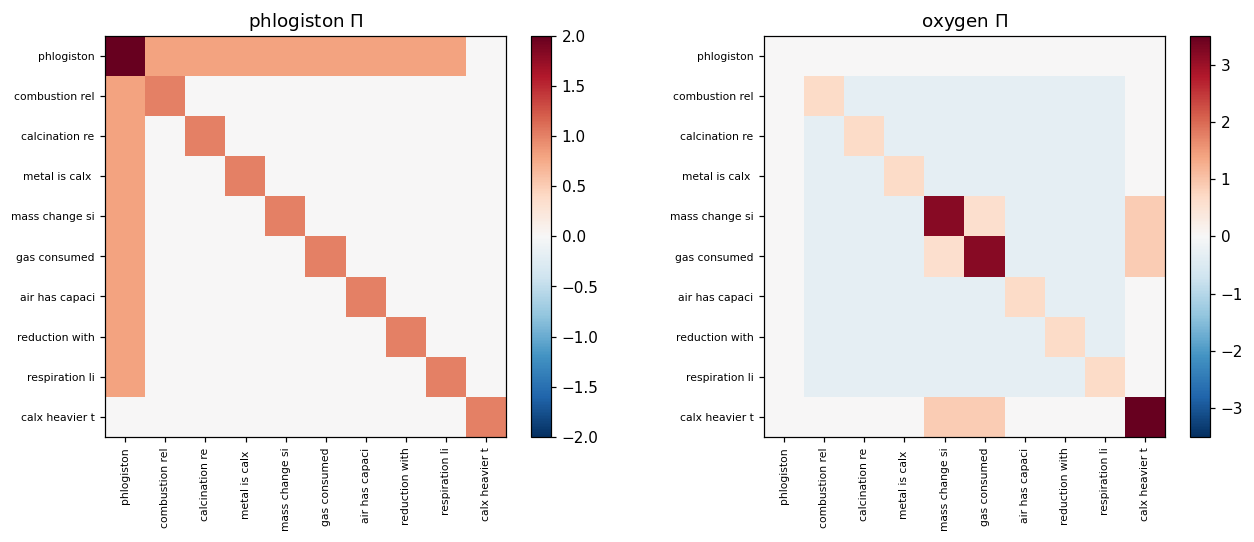

phlogiston is a hub (row 0 dense); oxygen has no hub but a mass-law block among nodes 4,5,9


In [2]:
cfg = ph.StructuralConfig()
phlog = ph.phlogiston_prior(cfg)
oxy   = ph.oxygen_prior(cfg)
names = cfg.node_names
short = [n.replace('_', ' ')[:14] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, net, title in [(axes[0], phlog, 'phlogiston $\\Pi$'), (axes[1], oxy, 'oxygen $\\Pi$')]:
    M = np.asarray(net.Pi)
    im = ax.imshow(M, cmap='RdBu_r', vmin=-np.abs(M).max(), vmax=np.abs(M).max())
    ax.set_title(title); ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels(short, rotation=90, fontsize=7); ax.set_yticklabels(short, fontsize=7)
    ax.grid(False); fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()
print('phlogiston is a hub (row 0 dense); oxygen has no hub but a mass-law block among nodes 4,5,9')


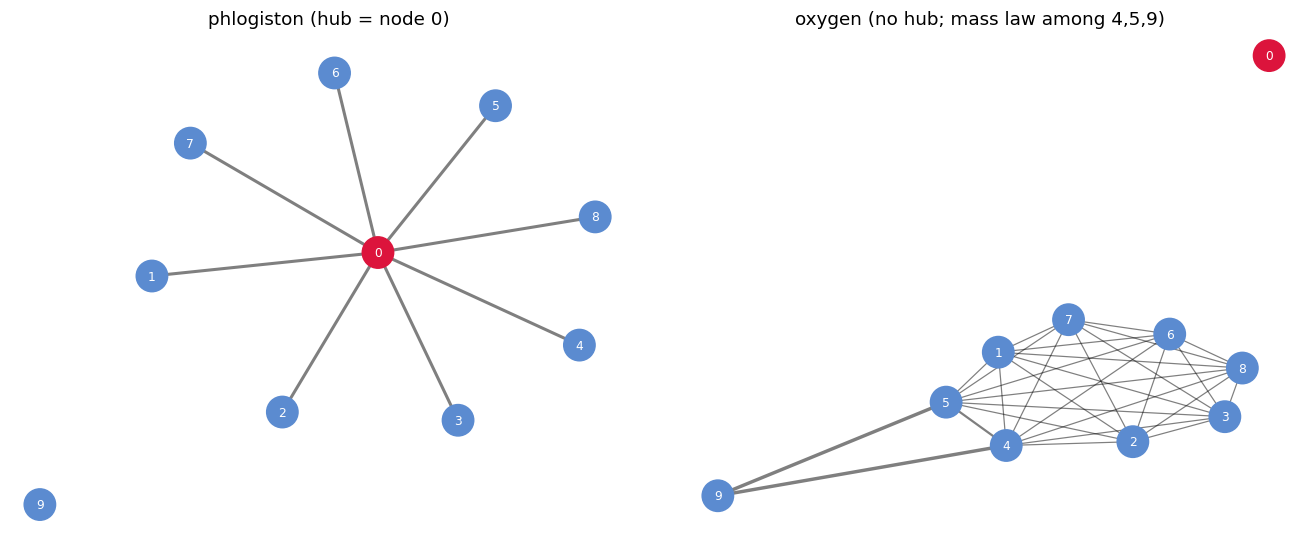

In [3]:
# the same two beliefs as graphs
def draw_net(ax, net, title, hub=None):
    M = np.asarray(net.Pi); d = M.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(d))
    for i in range(d):
        for j in range(i+1, d):
            if abs(M[i, j]) > 1e-6:
                G.add_edge(i, j, w=abs(M[i, j]))
    pos = nx.spring_layout(G, seed=1, k=0.9)
    cols = ['crimson' if (hub and net.names[i] == ph.HUB) else '#5b8bd0' for i in range(d)]
    ws = [2.5*G[u][v]['w'] for u, v in G.edges()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=cols, node_size=420)
    nx.draw_networkx_edges(G, pos, ax=ax, width=ws, alpha=0.5)
    nx.draw_networkx_labels(G, pos, ax=ax, labels={i: i for i in range(d)}, font_size=8, font_color='white')
    ax.set_title(title); ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
draw_net(axes[0], phlog, 'phlogiston (hub = node 0)', hub=True)
draw_net(axes[1], oxy, 'oxygen (no hub; mass law among 4,5,9)', hub=True)
plt.tight_layout(); plt.show()


## 2. The carry-over: marginalizing the phlogiston hub *writes* the mass law

Removing the hub by Schur complement is not free: it deposits fill-in edges among the hub's former
neighbours. That fill-in **is** the Lavoisian direct mass law (the paper's Appendix $A\to B$ step).
The Frobenius mass of the fill-in is the literal *importance* of a node.


survivor basis: ('combustion_releases', 'calcination_releases', 'metal_is_calx_plus_phlog', 'mass_change_sign', 'gas_consumed', 'air_has_capacity', 'reduction_with_charcoal', 'respiration_like_combustion', 'calx_heavier_than_metal')
carryover_mass(phlogiston hub) = 2.560
carryover_mass(belt node calx_heavier) = 0.000


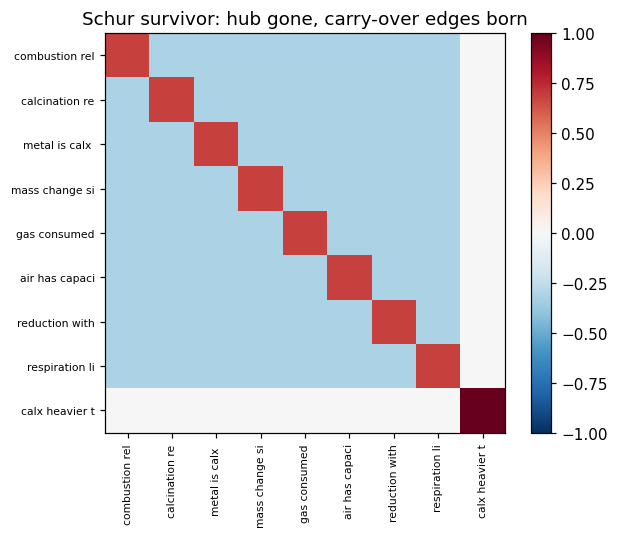

A hub leaves a dense ghost; a belt node leaves none. Importance = fill-in.


In [4]:
surv = st.schur_marginalize(phlog, (ph.HUB,))
print('survivor basis:', surv.names)
print('carryover_mass(phlogiston hub) = %.3f' % obs.carryover_mass(phlog, (ph.HUB,)))
print('carryover_mass(belt node calx_heavier) = %.3f' % obs.carryover_mass(phlog, ('calx_heavier_than_metal',)))

# show the born edges: survivor off-diagonals that the hub created
fig, ax = plt.subplots(figsize=(6, 5))
M = np.asarray(surv.Pi); v = np.abs(M).max()
im = ax.imshow(M, cmap='RdBu_r', vmin=-v, vmax=v)
sn = [n.replace('_', ' ')[:14] for n in surv.names]
ax.set_xticks(range(len(sn))); ax.set_yticks(range(len(sn)))
ax.set_xticklabels(sn, rotation=90, fontsize=7); ax.set_yticklabels(sn, fontsize=7); ax.grid(False)
ax.set_title('Schur survivor: hub gone, carry-over edges born'); fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()
print('A hub leaves a dense ghost; a belt node leaves none. Importance = fill-in.')


## 3. Single agent: the evidence envelope crosses, BMR falsifies the claim

One agent accumulates Fisher information from the regime-dependent world and tracks the running
model log-evidence of each candidate paradigm. The **upper envelope** is the held paradigm; the
crossing is the paradigm shift. Below it, the **BMR Bayes factor** for phlogiston's falsifiable
commitment (*the calx is lighter*): positive while the data vindicate it, negative once they refute
it. Both lag the world-change at $t_{\text{shift}}$ -- **paradigm inertia**.


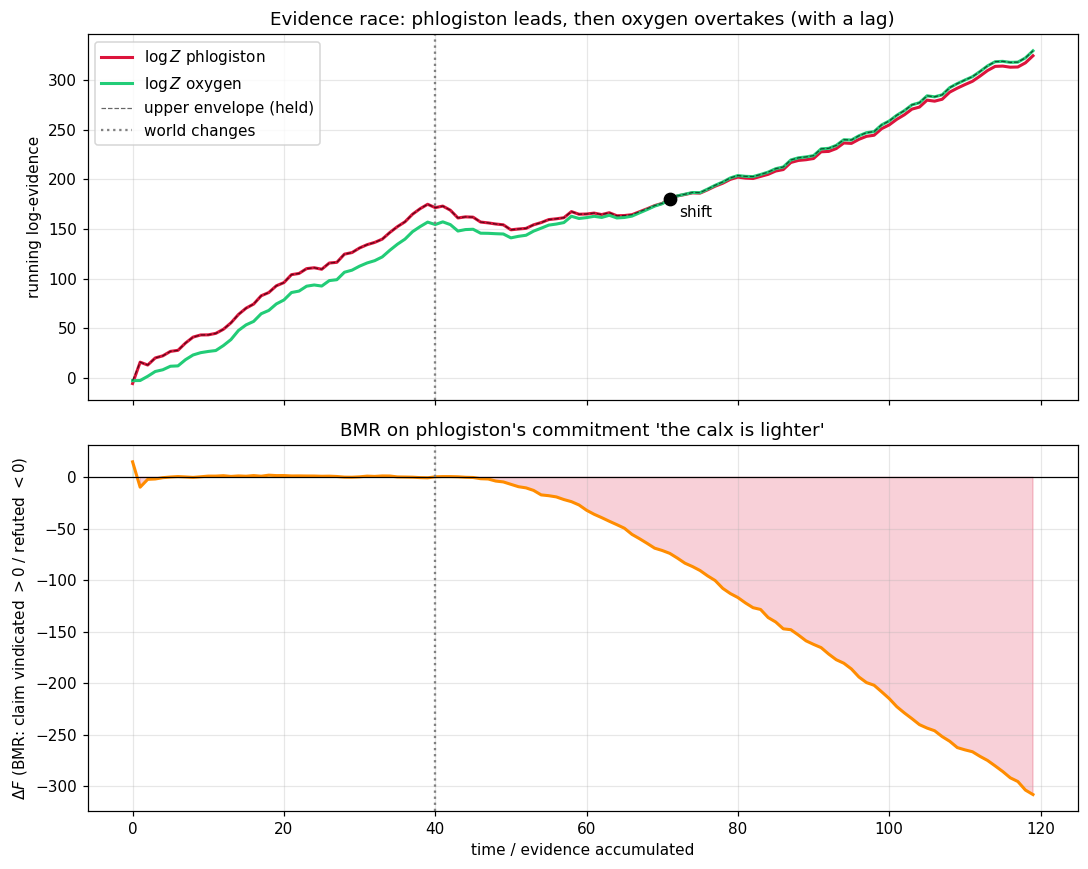

world changes at t=40; evidence envelope crosses at t=71 (lag 31)


In [5]:
race = st.evidence_race(cfg, jax.random.PRNGKey(0))
t = np.asarray(race['t'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(t, np.asarray(race['logZ_phlog']), color='crimson', lw=2, label='$\\log Z$ phlogiston')
ax1.plot(t, np.asarray(race['logZ_oxy']), color='#2c7', lw=2, label='$\\log Z$ oxygen')
env = np.maximum(np.asarray(race['logZ_phlog']), np.asarray(race['logZ_oxy']))
ax1.plot(t, env, 'k--', lw=0.8, alpha=0.6, label='upper envelope (held)')
ax1.axvline(cfg.t_shift, color='grey', ls=':', label='world changes')
gap = np.asarray(race['gap']); cr = np.where(np.diff(np.sign(gap)) != 0)[0]
for c in cr:
    if c >= cfg.t_shift: ax1.plot(c, env[c], 'ko', ms=8); ax1.annotate('shift', (c, env[c]), textcoords='offset points', xytext=(6, -12))
ax1.set_ylabel('running log-evidence'); ax1.legend(loc='upper left'); ax1.set_title('Evidence race: phlogiston leads, then oxygen overtakes (with a lag)')

dF = np.asarray(race['delta_F'])
ax2.plot(t, dF, color='darkorange', lw=2)
ax2.axhline(0, color='k', lw=0.8); ax2.axvline(cfg.t_shift, color='grey', ls=':')
ax2.fill_between(t, 0, dF, where=(dF > 0), color='#2c7', alpha=0.2)
ax2.fill_between(t, 0, dF, where=(dF < 0), color='crimson', alpha=0.2)
ax2.set_ylabel('$\\Delta F$ (BMR: claim vindicated $>0$ / refuted $<0$)'); ax2.set_xlabel('time / evidence accumulated')
ax2.set_title("BMR on phlogiston's commitment 'the calx is lighter'")
plt.tight_layout(); plt.show()

shift_cross = cr[cr >= cfg.t_shift][0] if np.any(cr >= cfg.t_shift) else None
print(f'world changes at t={cfg.t_shift}; evidence envelope crosses at t={shift_cross} (lag {None if shift_cross is None else shift_cross-cfg.t_shift})')


## 4. Multi-agent full communication — via the class-based kernel

Now $N$ agents on a small-world social graph (`src/network.build_adjacency`), each carrying a full
phlogiston net. Every round they transmit their **entire** $(\Pi, h)$ and fuse by trust-weighted
precision addition $\Pi_i \leftarrow \sum_j W_{ij}\Pi_j$ — the matrix lift of the scalar
`precision_pool`.

From here on the experiment is driven by the **kernel** (`src/structural/kernel.py`): the whole
rollout is a class you initialise once and then run.

```python
net = Network.init(cfg)        # build the graph + hand each agent its prior   ← "the graph"
m_t, grav_t = net.run_trace()  # one @eqx.filter_jit lax.scan over the horizon  ← "then compiled"
net.isolated().run_trace()     # the no-communication baseline (W = identity)
net.agent(0)                   # one Agent you can hold: .observe / .update / .posterior_mean
```

`Network`/`Agent` are `equinox.Module` pytrees, so the readable per-agent object and the batched
compiled sweep are the *same code* — and because the loop stays inside a single JIT'd `scan` (no
per-step host sync) it runs ~100× faster than the old python-loop `step`. We confirm that below,
then compare the population order parameter $m(t)$ **with** vs **without** communication.

legacy step.run (python loop):  5867.8 ms   kernel run_trace (jit):   46.3 ms   speedup:   127x


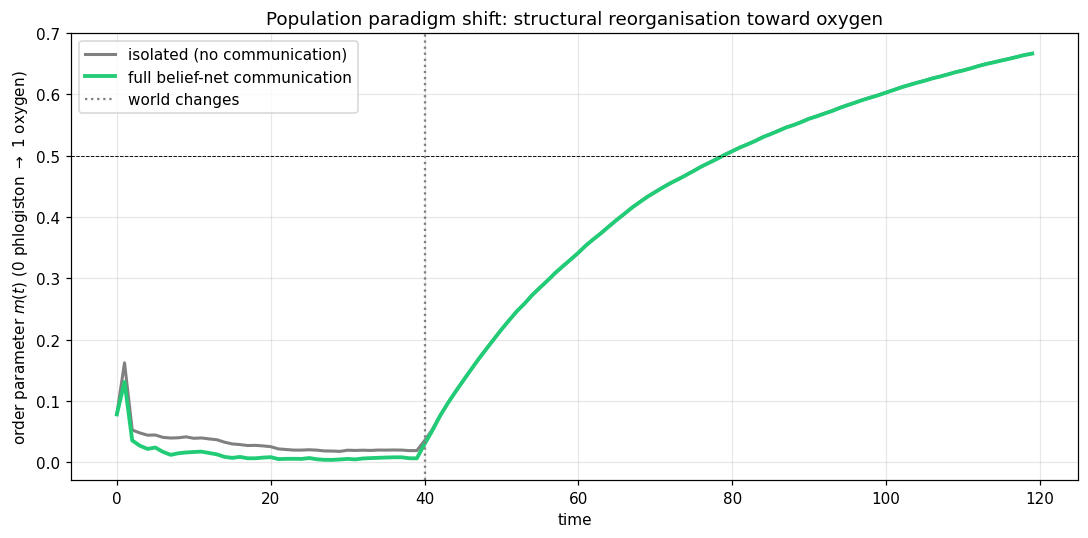

half-crossing: fused t=78, isolated t=78 (t_shift=40)


agent(0): a Gaussian belief net on 10 commitments; posterior oxygen-index = 0.000


In [6]:
cfg_m = ph.StructuralConfig(n_agents=60, n_steps=120, t_shift=40)
key = jax.random.PRNGKey(0)

# Build the graph once, then run the compiled rollout. `net` is a Network; `m_fused`
# is the population order parameter trajectory, read to the host once at the end.
net = Network.init(cfg_m, key)
m_fused, _grav = net.run_trace()                       # fused (full communication)
m_iso, _ = net.isolated().run_trace()                  # no-communication baseline (W = I)

# --- the JIT win: kernel scan vs the legacy python-loop step (host sync every step) ---
t0 = time.perf_counter(); _ = S.run(cfg_m, key); t_legacy = time.perf_counter() - t0
_ = net.run_trace()                                    # warm the compile cache
t0 = time.perf_counter()
for _ in range(5):
    net.run_trace()
t_kernel = (time.perf_counter() - t0) / 5
print(f'legacy step.run (python loop): {t_legacy*1e3:7.1f} ms   '
      f'kernel run_trace (jit): {t_kernel*1e3:6.1f} ms   speedup: {t_legacy/t_kernel:5.0f}x')

tt = np.arange(cfg_m.n_steps)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tt, m_iso, color='grey', lw=2, label='isolated (no communication)')
ax.plot(tt, m_fused, color='#2c7', lw=2.5, label='full belief-net communication')
ax.axhline(0.5, color='k', lw=0.6, ls='--'); ax.axvline(cfg_m.t_shift, color='grey', ls=':', label='world changes')
ax.set_xlabel('time'); ax.set_ylabel('order parameter $m(t)$ (0 phlogiston $\\to$ 1 oxygen)')
ax.set_title('Population paradigm shift: structural reorganisation toward oxygen'); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

def cross_half(m):
    c = np.where(np.diff(np.sign(m - 0.5)) != 0)[0]
    return int(c[0]) if len(c) else None
print(f'half-crossing: fused t={cross_half(m_fused)}, isolated t={cross_half(m_iso)} (t_shift={cfg_m.t_shift})')

# the readable per-agent surface: one Agent you can hold and inspect
a0 = net.agent(0)
print(f'agent(0): a Gaussian belief net on {len(a0.names)} commitments; '
      f'posterior oxygen-index = {float(obs.oxygen_index(a0.posterior_mean(), a0.names, ph.DISAGREEMENT_NODES, cfg_m.mu_phlog_mass, cfg_m.mu_oxy_mass)):.3f}')

## 4b. Heterogeneous schools: precision is the lock-in knob

Section 4's null came from a *homogeneous* population. Here we break the symmetry the way the
structural model allows: agents have no utility function, so the analogue of a "different initial
utility weighting" is a **different prior** — its **stance** (the prior mean on the disagreement /
mass-law nodes $\mu_{\text{phlog mass}}$, phlogiston-committed $<0<$ oxygen-leaning) and its
**confidence** (the prior precision, `prec_scale` $\times$ `base_prec`/`hub_self_prec`). We split
$N=60$ into three stance$\times$confidence **schools**, one of which — the *entrenched
phlogistonist* bloc — is given a very high precision.

Two things matter, and the second is the point of the experiment:

1. **A high-precision prior refuses to update.** Each round an agent adds Fisher information
   ($\Pi\mathrel{+}=J$); a prior precision comparable to the *accumulated* evidence is never
   overwhelmed within the horizon. Below we sweep `prec_scale` and watch a bloc's order parameter
   stop crossing $\tfrac12$ — it **stops changing its mind**. This is paradigm lock-in, and
   precision is its knob.

2. **An entrenched minority captures the majority through communication.** Fusion
   ($\Pi_i\leftarrow\sum_j W_{ij}\Pi_j$) is **precision-weighted**, so the consensus it manufactures
   sits at the precision-weighted centre of mass. A small high-precision bloc therefore drags the
   whole population toward its view. In isolation the open/proto-oxygenist majority flips to oxygen;
   *with* communication the entrenched minority pulls the population **back below the shift
   threshold and prevents the collective paradigm change.** Communication does not just average — it
   lets a committed core hold the field.

Honest caveat: because `step` accumulates Fisher information with **no forgetting**, this lock-in is
over the relevant *horizon* — run long enough and unbounded evidence eventually wins (the substrate
is monostable, cf. nb13). *Permanent* lock-in (true bistability) needs a precision cap / belief
forgetting, the natural next mechanism.


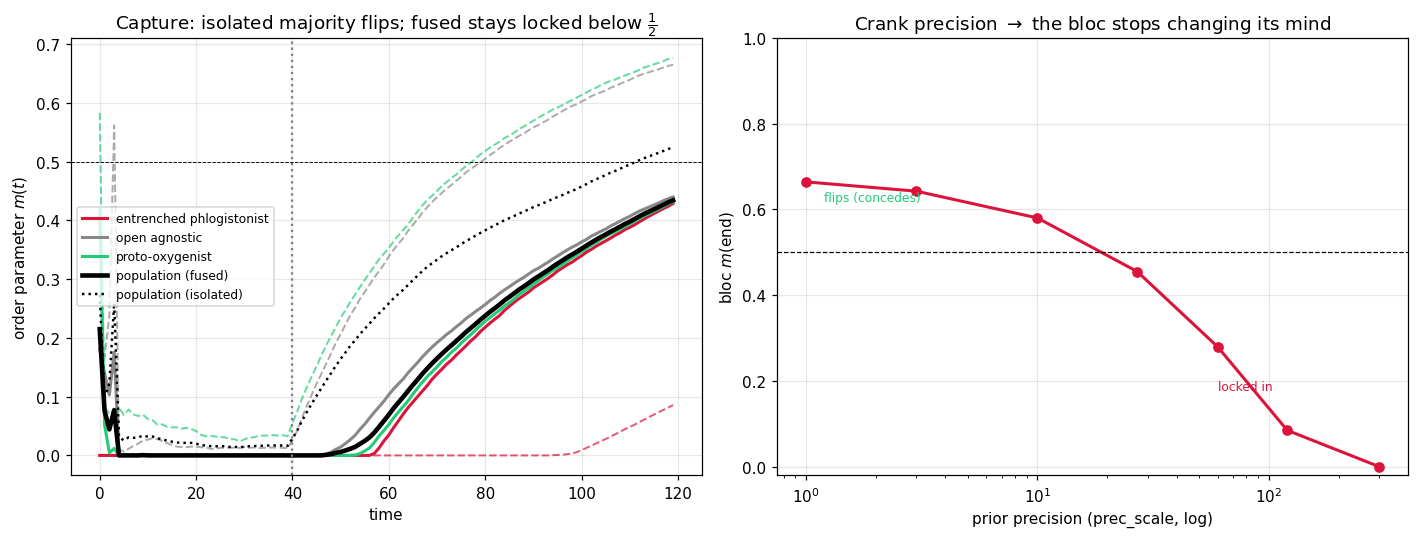

population half-crossing:  fused t=None (None = paradigm shift PREVENTED), isolated t=111  (world changes at t=40)
  entrenched phlogistonist: isolated 0.00->0.09, fused 0.00->0.43
  open agnostic           : isolated 0.19->0.66, fused 0.18->0.44
  proto-oxygenist         : isolated 0.58->0.68, fused 0.42->0.43
lock-in threshold: bloc stops crossing 1/2 at prec_scale >= 27 (analytic ~27 for this horizon).
--> A high-precision entrenched minority both refuses to update AND, via precision-weighted fusion, captures the majority and prevents the population paradigm shift.


In [7]:
# Three stance x confidence schools; the phlogistonist bloc is ENTRENCHED (high precision).
cfg_h = ph.StructuralConfig(n_agents=60, n_steps=120, t_shift=40)
schools = [
    dict(count=15, stance=-2.0, prec_scale=120.0, label='entrenched phlogistonist', color='crimson'),
    dict(count=25, stance= 0.0, prec_scale=0.5,   label='open agnostic',            color='#888888'),
    dict(count=20, stance=+0.4, prec_scale=1.0,   label='proto-oxygenist',          color='#2c7'),
]
gid = np.repeat(np.arange(len(schools)), [g['count'] for g in schools])   # per-agent school id
key = jax.random.PRNGKey(0)

# One compiled per-agent trajectory each (fused vs isolated); per-school curve = column mean.
def school_curves(net):
    oxy = net.run_trace_index()                                # (T, N)
    pop = oxy.mean(axis=1)
    sch = np.stack([oxy[:, gid == g].mean(axis=1) for g in range(len(schools))], axis=1)
    return pop, sch

net_h = Network.init(cfg_h, key, groups=schools)
mpop_f, msch_f = school_curves(net_h)                          # fused
mpop_i, msch_i = school_curves(net_h.isolated())               # isolated (W = I)

# precision lock-in sweep: an isolated phlogiston bloc, m(end) as prec_scale grows.
# run_final fast-forwards the whole 120-step rollout in one jitted scan per config.
ps_grid = np.array([1, 3, 10, 27, 60, 120, 300], float)
m_end = []
for ps in ps_grid:
    cfg_s = ph.StructuralConfig(n_agents=20, n_steps=cfg_h.n_steps, t_shift=cfg_h.t_shift)
    final = Network.init(cfg_s, key,
                         groups=[dict(count=20, stance=-2.0, prec_scale=float(ps))]).run_final()
    m_end.append(float(obs.order_parameter(final.agents.Pi, final.agents.h, cfg_s.node_names,
                                           ph.DISAGREEMENT_NODES, cfg_s.mu_phlog_mass, cfg_s.mu_oxy_mass)))
m_end = np.asarray(m_end)

tt = np.arange(cfg_h.n_steps)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# (i) capture: per-school fused (solid) vs isolated (dashed) + population (thick)
for g, sc in enumerate(schools):
    axL.plot(tt, msch_f[:, g], color=sc['color'], lw=2.0, label=sc['label'])
    axL.plot(tt, msch_i[:, g], color=sc['color'], lw=1.3, ls='--', alpha=0.7)
axL.plot(tt, mpop_f, color='k', lw=3, label='population (fused)')
axL.plot(tt, mpop_i, color='k', lw=1.6, ls=':', label='population (isolated)')
axL.axhline(0.5, color='k', lw=0.6, ls='--'); axL.axvline(cfg_h.t_shift, color='grey', ls=':')
axL.set_xlabel('time'); axL.set_ylabel('order parameter $m(t)$')
axL.set_title('Capture: isolated majority flips; fused stays locked below $\\frac{1}{2}$')
axL.legend(loc='center left', fontsize=8)

# (ii) precision is the lock-in knob
axR.plot(ps_grid, m_end, 'o-', color='crimson', lw=2)
axR.axhline(0.5, color='k', lw=0.8, ls='--')
axR.set_xscale('log'); axR.set_xlabel('prior precision (prec_scale, log)')
axR.set_ylabel('bloc $m$(end)'); axR.set_ylim(-0.02, 1.0)
axR.set_title('Crank precision $\\to$ the bloc stops changing its mind')
axR.annotate('flips (concedes)', (1.2, 0.62), fontsize=8, color='#2c7')
axR.annotate('locked in', (60, 0.18), fontsize=8, color='crimson')
plt.tight_layout(); plt.show()

cross_half = lambda m: (lambda c: int(c[0]) if len(c) else None)(
    np.where(np.diff(np.sign(m - 0.5)) != 0)[0])
print(f'population half-crossing:  fused t={cross_half(mpop_f)} (None = paradigm shift PREVENTED), '
      f'isolated t={cross_half(mpop_i)}  (world changes at t={cfg_h.t_shift})')
for g, sc in enumerate(schools):
    print(f'  {sc["label"]:24s}: isolated {msch_i[0,g]:.2f}->{msch_i[-1,g]:.2f}, '
          f'fused {msch_f[0,g]:.2f}->{msch_f[-1,g]:.2f}')
lock = ps_grid[m_end < 0.5]
print(f'lock-in threshold: bloc stops crossing 1/2 at prec_scale >= {lock[0]:.0f}'
      f' (analytic ~27 for this horizon).')
print('--> A high-precision entrenched minority both refuses to update AND, via precision-weighted'
      ' fusion, captures the majority and prevents the population paradigm shift.')

## 5. Summary

- The **phlogiston hub's Schur fill-in is the Lavoisian mass law**: removing the hidden principle
  does not delete it, it re-precipitates as direct couplings among the surviving commitments.
- The **upper envelope of the candidate log-evidences is the held paradigm**; its crossing is the
  paradigm shift, and it **lags** the world-change -- phlogiston banks an evidence lead during its
  good regime that the new data take time to erode (paradigm inertia).
- **BMR localises falsification** to the specific vulnerable commitment (*calx lighter*): a modest
  Occam vindication while the regime holds, a catastrophic refutation once gravimetry reveals the
  mass gain.
- **Full belief-net communication** is a one-line precision addition that carries the
  precision-weighted mean for free. In a **homogeneous** population (Section 4) it is the identity on
  the mean trajectory: fused and isolated cross at the *same* time.
- **Heterogeneous schools (Section 4b): precision is the lock-in knob.** Giving sub-populations
  different prior *stances* and *confidences* makes the social channel do real work, with two
  consequences. (1) **A high-precision prior refuses to update**: because each round only *adds*
  Fisher information, a prior precision comparable to the accumulated evidence is never overwhelmed
  within the horizon -- crank `prec_scale` and a bloc's order parameter stops crossing $\tfrac12$
  (it stops changing its mind). (2) **An entrenched minority captures the majority**: fusion is
  precision-weighted, so a small high-precision bloc drags the consensus to its view. In isolation
  the open/proto-oxygenist majority flips to oxygen (population crosses $\tfrac12$); *with*
  communication the entrenched minority pulls the whole population back below the threshold and
  **prevents the collective paradigm shift**. Communication does not merely average -- it lets a
  committed core hold the field.
- **Honest caveat (monostable substrate).** With no forgetting, `step` accumulates Fisher
  information without bound, so this lock-in is over the relevant *horizon*: run long enough and the
  evidence eventually wins (consistent with nb13's monostability). *Permanent* lock-in -- a true
  second attractor -- requires a precision cap / belief-forgetting term, the natural next mechanism
  on this substrate.
